<a href="https://colab.research.google.com/github/sonalisanjeevprabu18/QLD/blob/main/gpt2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformers torch datasets accelerate

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import json
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cpu":
    print("WARNING: No GPU detected. Go to Runtime > Change runtime type > T4 GPU")

Using device: cuda


In [2]:

model_name = "gpt2"  # GPT-2 small, 117M params, 12 layers, d_model=768
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name).to(device)
tokenizer.pad_token = tokenizer.eos_token

print(f"Model loaded: {model_name}")
print(f"Number of layers: {model.config.n_layer}")
print(f"Hidden dimension (d_model): {model.config.n_embd}")


class ResidualStreamCapture:
    """
    Captures residual stream activations from a chosen GPT-2 layer.
    This is the bridge between the base model and the SAE monitoring
    module described in your Methodology Section B.
    """
    def __init__(self, model, layer_idx):
        self.layer_idx = layer_idx
        self.activations = None
        self.hook_handle = None
        self._register_hook(model)

    def _hook_fn(self, module, input, output):
        # GPT2Block output is a tuple; index 0 is the hidden state (residual stream)
        # VERIFY: this tuple structure against the transformers version installed —
        # it has been consistent for GPT2Block but library internals can change.
        hidden_state = output[0] if isinstance(output, tuple) else output
        self.activations = hidden_state.detach()

    def _register_hook(self, model):
        target_layer = model.transformer.h[self.layer_idx]
        self.hook_handle = target_layer.register_forward_hook(self._hook_fn)

    def remove(self):
        if self.hook_handle is not None:
            self.hook_handle.remove()

# Example: capture residual stream at layer 6 (middle of the network)
LAYER_IDX = 6
capture = ResidualStreamCapture(model, LAYER_IDX)

# Quick sanity check
test_input = tokenizer("The capital of France is", return_tensors="pt").to(device)
with torch.no_grad():
    _ = model(**test_input)

print(f"\nCaptured activation shape: {capture.activations.shape}")
print(f"Expected shape: [batch_size, seq_len, {model.config.n_embd}]")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model loaded: gpt2
Number of layers: 12
Hidden dimension (d_model): 768

Captured activation shape: torch.Size([1, 5, 768])
Expected shape: [batch_size, seq_len, 768]


In [3]:

class TopKSAE(nn.Module):
    """
    Sparse Autoencoder with exact top-k sparsity.

    d_model: dimension of the residual stream (768 for GPT-2 small)
    d_hidden: size of the overcomplete feature dictionary
    k: number of active features per token (sparsity level, L0)
    """
    def __init__(self, d_model, d_hidden, k):
        super().__init__()
        self.d_model = d_model
        self.d_hidden = d_hidden
        self.k = k

        self.encoder = nn.Linear(d_model, d_hidden, bias=True)
        self.decoder = nn.Linear(d_hidden, d_model, bias=True)

        # Standard SAE init: decoder columns unit-norm, encoder = decoder^T
        # This initialization scheme is common in SAE literature (e.g. Anthropic's
        # SAE work) for training stability — verify against current best practice
        # if you want to deviate from this.
        with torch.no_grad():
            self.decoder.weight.data = F.normalize(self.decoder.weight.data, dim=0)
            self.encoder.weight.data = self.decoder.weight.data.t().clone()

    def encode(self, h):
        """
        h: [batch, seq_len, d_model] or [N, d_model]
        Returns sparse latent z with only top-k entries nonzero per row.
        """
        z_pre = F.relu(self.encoder(h))  # pre-activation, non-negative

        # TopK masking: keep only the k largest activations per token,
        # zero out the rest. This enforces exact L0 = k sparsity.
        topk_vals, topk_idx = torch.topk(z_pre, self.k, dim=-1)
        z = torch.zeros_like(z_pre)
        z.scatter_(-1, topk_idx, topk_vals)
        return z

    def decode(self, z):
        return self.decoder(z)

    def forward(self, h):
        z = self.encode(h)
        h_recon = self.decode(z)
        return z, h_recon

    def reconstruction_loss(self, h, h_recon):
        return F.mse_loss(h_recon, h)


# --- Instantiate the SAE for our chosen layer ---
D_MODEL = model.config.n_embd        # 768 for GPT-2 small
D_HIDDEN = 8192                       # overcomplete dictionary; scale up later
K = 32                                # sparsity level (L0)

sae = TopKSAE(d_model=D_MODEL, d_hidden=D_HIDDEN, k=K).to(device)

print(f"SAE initialized:")
print(f"  Input dim (d_model): {D_MODEL}")
print(f"  Dictionary size (d_hidden): {D_HIDDEN}")
print(f"  Sparsity (k): {K} active features per token")
print(f"  Total parameters: {sum(p.numel() for p in sae.parameters()):,}")

# Sanity check with the captured activation from Cell 2
with torch.no_grad():
    h_sample = capture.activations  # [1, seq_len, 768]
    z_sample, h_recon_sample = sae(h_sample)
    print(f"\nz (sparse latent) shape: {z_sample.shape}")
    print(f"Active features per token: {(z_sample != 0).sum(dim=-1).float().mean().item():.1f} (should equal k={K})")
    print(f"Reconstruction MSE (untrained SAE, expect high): {sae.reconstruction_loss(h_sample, h_recon_sample).item():.4f}")

SAE initialized:
  Input dim (d_model): 768
  Dictionary size (d_hidden): 8192
  Sparsity (k): 32 active features per token
  Total parameters: 12,591,872

z (sparse latent) shape: torch.Size([1, 5, 8192])
Active features per token: 32.0 (should equal k=32)
Reconstruction MSE (untrained SAE, expect high): 2080.9932


In [4]:

physics_qa_pairs = [
    ("What is Newton's second law?", "Newton's second law states that force equals mass times acceleration, F=ma."),
    ("Why does a ball fall to the ground?", "A ball falls due to gravity, which pulls objects with mass toward each other."),
    ("What is kinetic energy?", "Kinetic energy is the energy an object has due to its motion, calculated as one half mass times velocity squared."),
    ("Explain conservation of momentum.", "Conservation of momentum states that the total momentum of a closed system remains constant unless acted on by an external force."),
    ("What causes friction?", "Friction is caused by microscopic irregularities between two surfaces in contact, resisting relative motion."),
    ("What is the difference between speed and velocity?", "Speed is a scalar measuring how fast something moves, while velocity is a vector that includes direction."),
    ("Why do objects in space float?", "Objects in space appear to float because they are in free fall, continuously falling around a body like Earth without hitting it, which is the state of orbit."),
    ("What is Ohm's law?", "Ohm's law states that voltage equals current multiplied by resistance, V=IR."),
    ("Explain the concept of entropy.", "Entropy is a measure of disorder in a system, and the second law of thermodynamics states it tends to increase over time in isolated systems."),
    ("What is a wave?", "A wave is a disturbance that transfers energy through a medium or space without permanently displacing matter."),
    ("How does a pendulum work?", "A pendulum swings due to gravity pulling it downward while its momentum carries it past the lowest point, converting potential and kinetic energy back and forth."),
    ("What is the photoelectric effect?", "The photoelectric effect is the emission of electrons from a material when light of sufficient frequency shines on it, demonstrating the particle nature of light."),
]

# Format as instruction-response pairs (simple template)
def format_example(question, answer):
    return f"Question: {question}\nAnswer: {answer}{tokenizer.eos_token}"

formatted_texts = [format_example(q, a) for q, a in physics_qa_pairs]

print(f"Dataset size: {len(formatted_texts)} examples")
print(f"\nExample:\n{formatted_texts[0]}")

# Tokenize
def tokenize_batch(texts, max_length=128):
    return tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

tokenized = tokenize_batch(formatted_texts)
print(f"\nTokenized input_ids shape: {tokenized['input_ids'].shape}")
# ============================================================
# CELL 5 — Feature Monitoring Module
# Implements Methodology Section D: training-time feature monitoring
# ============================================================
# For each feature j at layer L and training step t, we track:
#   f(j, L, t) — activation frequency: proportion of tokens activating feature j
#   m(j, L, t) — activation magnitude: mean activation value when active
#   delta(j, L, t) — drift: change in magnitude since last checkpoint
#
# This produces the "continuous developmental record" your methodology
# document calls the primary output of the monitoring phase.

class FeatureMonitor:
    """
    Tracks per-feature statistics across training steps.
    This is the monitoring module described in Methodology Section D.
    """
    def __init__(self, d_hidden, layer_idx):
        self.d_hidden = d_hidden
        self.layer_idx = layer_idx
        self.history = []  # list of dicts, one per checkpoint
        self._prev_magnitude = None  # for computing drift

    def record_checkpoint(self, z_batch, step):
        """
        z_batch: [N_tokens, d_hidden] sparse latent activations from a batch
        step: current training step (int)
        """
        with torch.no_grad():
            active_mask = (z_batch != 0).float()  # [N_tokens, d_hidden]

            # f(j, L, t): fraction of tokens where feature j is active
            frequency = active_mask.mean(dim=0)  # [d_hidden]

            # m(j, L, t): mean activation magnitude among tokens where active
            sum_active = z_batch.sum(dim=0)
            count_active = active_mask.sum(dim=0).clamp(min=1)
            magnitude = sum_active / count_active  # [d_hidden]

            # delta(j, L, t): change in magnitude since previous checkpoint
            if self._prev_magnitude is None:
                drift = torch.zeros_like(magnitude)
            else:
                drift = magnitude - self._prev_magnitude

            self._prev_magnitude = magnitude.clone()

            checkpoint = {
                "step": step,
                "frequency": frequency.cpu().numpy(),
                "magnitude": magnitude.cpu().numpy(),
                "drift": drift.cpu().numpy(),
            }
            self.history.append(checkpoint)

    def get_top_features(self, step_idx=-1, top_n=10, by="frequency"):
        """Inspect the most active features at a given checkpoint."""
        ckpt = self.history[step_idx]
        scores = ckpt[by]
        top_idx = np.argsort(scores)[-top_n:][::-1]
        return [(int(i), float(scores[i])) for i in top_idx]

    def get_drifting_features(self, step_idx=-1, top_n=10):
        """
        Features with the largest absolute drift — candidates for the
        developer intervention protocol in Methodology Section E.
        """
        ckpt = self.history[step_idx]
        drift = ckpt["drift"]
        top_idx = np.argsort(np.abs(drift))[-top_n:][::-1]
        return [(int(i), float(drift[i])) for i in top_idx]

    def plot_feature_trajectory(self, feature_ids, metric="magnitude"):
        """Plot how specific features evolve across training steps."""
        steps = [c["step"] for c in self.history]
        plt.figure(figsize=(8, 4))
        for fid in feature_ids:
            values = [c[metric][fid] for c in self.history]
            plt.plot(steps, values, label=f"feature {fid}")
        plt.xlabel("Training step")
        plt.ylabel(metric)
        plt.title(f"Feature {metric} over training (layer {self.layer_idx})")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()


monitor = FeatureMonitor(d_hidden=D_HIDDEN, layer_idx=LAYER_IDX)
print("FeatureMonitor initialized.")

Dataset size: 12 examples

Example:
Question: What is Newton's second law?
Answer: Newton's second law states that force equals mass times acceleration, F=ma.<|endoftext|>

Tokenized input_ids shape: torch.Size([12, 128])
FeatureMonitor initialized.


In [5]:

class InterventionController:

    def __init__(self, sae):
        self.sae = sae
        self.suppressed_features = set()   # weight suppression (reversible)
        self.eliminated_features = set()   # permanent elimination
        self.intervention_log = []

    def suppress(self, feature_idx, step):
        """Weight suppression: zero the feature, slot remains in dictionary."""
        self.suppressed_features.add(feature_idx)
        self.intervention_log.append({
            "step": step, "feature": feature_idx, "action": "suppress"
        })

    def restore(self, feature_idx, step):
        """Reverse a suppression."""
        self.suppressed_features.discard(feature_idx)
        self.intervention_log.append({
            "step": step, "feature": feature_idx, "action": "restore"
        })

    def eliminate(self, feature_idx, step):
        """Permanent elimination — also zeros decoder weights for this feature."""
        self.eliminated_features.add(feature_idx)
        with torch.no_grad():
            self.sae.decoder.weight.data[:, feature_idx] = 0.0
            self.sae.encoder.weight.data[feature_idx, :] = 0.0
            self.sae.encoder.bias.data[feature_idx] = -1e4  # forces pre-relu negative
        self.intervention_log.append({
            "step": step, "feature": feature_idx, "action": "eliminate"
        })

    def apply_mask(self, z):

        if not self.suppressed_features:
            return z
        z = z.clone()
        idx = list(self.suppressed_features)
        z[..., idx] = 0.0
        return z

    def auto_intervene(self, monitor, drift_threshold=2.0, frequency_threshold=0.8, step=0):

        if not monitor.history:
            return []
        ckpt = monitor.history[-1]
        triggered = []
        for j in range(monitor.d_hidden):
            if abs(ckpt["drift"][j]) > drift_threshold and ckpt["frequency"][j] > frequency_threshold:
                if j not in self.suppressed_features and j not in self.eliminated_features:
                    self.suppress(j, step)
                    triggered.append(j)
        return triggered


intervention = InterventionController(sae)
print("InterventionController initialized.")
print("Use intervention.suppress(feature_idx, step) or intervention.eliminate(feature_idx, step)")
print("Or intervention.auto_intervene(monitor, ...) for automatic mode.")

InterventionController initialized.
Use intervention.suppress(feature_idx, step) or intervention.eliminate(feature_idx, step)
Or intervention.auto_intervene(monitor, ...) for automatic mode.


In [6]:

from torch.optim import AdamW

# --- Hyperparameters ---
N_EPOCHS = 20
BATCH_SIZE = 4
LR_MODEL = 5e-5
LR_SAE = 1e-3
SAE_LOSS_WEIGHT = 1.0       # weight on SAE reconstruction loss added to LM loss
MONITOR_EVERY = 5           # log feature stats every N steps
SPARSITY_WARMUP_STEPS = 0   # set >0 if you want to ramp k down over training

model.train()
sae.train()

model_optimizer = AdamW(model.parameters(), lr=LR_MODEL)
sae_optimizer = AdamW(sae.parameters(), lr=LR_SAE)

input_ids = tokenized["input_ids"].to(device)
attention_mask = tokenized["attention_mask"].to(device)
n_examples = input_ids.shape[0]

step = 0
loss_history = {"lm_loss": [], "sae_loss": [], "total_loss": []}

for epoch in range(N_EPOCHS):
    perm = torch.randperm(n_examples)
    for i in range(0, n_examples, BATCH_SIZE):
        batch_idx = perm[i:i + BATCH_SIZE]
        batch_input_ids = input_ids[batch_idx]
        batch_attention_mask = attention_mask[batch_idx]

        # --- Forward pass through GPT-2 ---
        # labels=batch_input_ids gives standard causal LM loss (next-token prediction)
        outputs = model(
            input_ids=batch_input_ids,
            attention_mask=batch_attention_mask,
            labels=batch_input_ids,
        )
        lm_loss = outputs.loss

        # --- Residual stream activation captured by the hook (Cell 2) ---
        h = capture.activations  # [batch, seq_len, d_model]

        # Flatten batch and sequence dims for the SAE, masking out padding tokens
        mask_flat = batch_attention_mask.reshape(-1).bool()
        h_flat = h.reshape(-1, h.shape[-1])[mask_flat]

        # --- SAE forward pass ---
        z, h_recon = sae(h_flat)
        z = intervention.apply_mask(z)  # apply any active suppressions

        sae_loss = sae.reconstruction_loss(h_flat, h_recon)

        # --- Combined loss ---
        total_loss = lm_loss + SAE_LOSS_WEIGHT * sae_loss

        # --- Backward pass ---
        model_optimizer.zero_grad()
        sae_optimizer.zero_grad()
        total_loss.backward()
        model_optimizer.step()
        sae_optimizer.step()

        loss_history["lm_loss"].append(lm_loss.item())
        loss_history["sae_loss"].append(sae_loss.item())
        loss_history["total_loss"].append(total_loss.item())

        # --- Monitoring checkpoint (Methodology Section D) ---
        if step % MONITOR_EVERY == 0:
            monitor.record_checkpoint(z.detach(), step)

        step += 1

    if epoch % 2 == 0:
        print(f"Epoch {epoch:3d} | LM loss: {lm_loss.item():.4f} | "
              f"SAE loss: {sae_loss.item():.4f} | Active features avg: "
              f"{(z != 0).sum(dim=-1).float().mean().item():.1f}")

print("\nTraining complete.")
print(f"Total monitoring checkpoints recorded: {len(monitor.history)}")

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch   0 | LM loss: 4.0474 | SAE loss: 273.5458 | Active features avg: 32.0
Epoch   2 | LM loss: 1.1837 | SAE loss: 237.5382 | Active features avg: 32.0
Epoch   4 | LM loss: 0.7763 | SAE loss: 214.2830 | Active features avg: 32.0
Epoch   6 | LM loss: 0.6397 | SAE loss: 172.8223 | Active features avg: 32.0
Epoch   8 | LM loss: 0.4962 | SAE loss: 176.0551 | Active features avg: 32.0
Epoch  10 | LM loss: 0.3890 | SAE loss: 165.5627 | Active features avg: 32.0
Epoch  12 | LM loss: 0.3989 | SAE loss: 111.8742 | Active features avg: 32.0
Epoch  14 | LM loss: 0.2455 | SAE loss: 103.4534 | Active features avg: 32.0
Epoch  16 | LM loss: 0.1953 | SAE loss: 85.6910 | Active features avg: 32.0
Epoch  18 | LM loss: 0.1829 | SAE loss: 61.2972 | Active features avg: 32.0

Training complete.
Total monitoring checkpoints recorded: 12


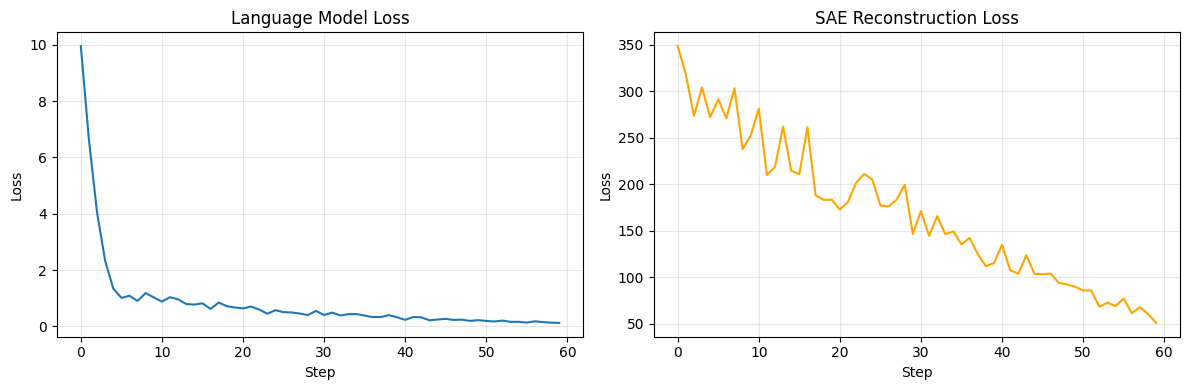

Top 10 most frequent features (final checkpoint):
  Feature 1235: active in 96.7% of tokens
  Feature 2141: active in 96.7% of tokens
  Feature 6347: active in 95.9% of tokens
  Feature 6683: active in 93.5% of tokens
  Feature 2536: active in 93.5% of tokens
  Feature 2980: active in 93.5% of tokens
  Feature 4754: active in 92.7% of tokens
  Feature 6502: active in 91.1% of tokens
  Feature 7698: active in 87.0% of tokens
  Feature 381: active in 81.3% of tokens

Top 10 features by drift magnitude (final checkpoint):
  Feature 1371: drift = +33.7556
  Feature 3731: drift = +29.2839
  Feature 1767: drift = +26.1441
  Feature 7020: drift = -25.3811
  Feature 532: drift = +25.0333
  Feature 1997: drift = +24.3043
  Feature 1772: drift = +24.2928
  Feature 548: drift = -24.2370
  Feature 7521: drift = -22.2703
  Feature 2741: drift = -22.1107


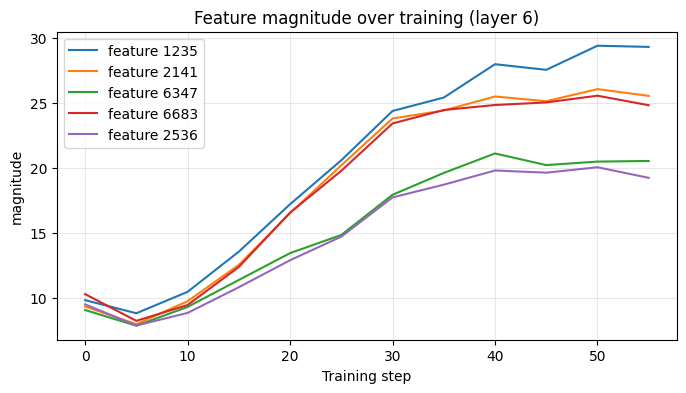

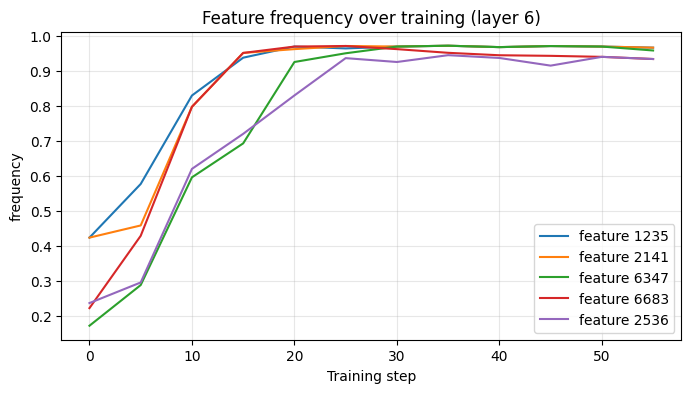


Developmental record saved to qld_developmental_record.json
File size check: this can get large with many checkpoints x d_hidden=8192


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(loss_history["lm_loss"], label="LM loss")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_title("Language Model Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(loss_history["sae_loss"], label="SAE reconstruction loss", color="orange")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Loss")
axes[1].set_title("SAE Reconstruction Loss")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- 2. Most frequently active features at the final checkpoint ---
print("Top 10 most frequent features (final checkpoint):")
top_freq = monitor.get_top_features(step_idx=-1, top_n=10, by="frequency")
for fid, score in top_freq:
    print(f"  Feature {fid}: active in {score*100:.1f}% of tokens")

# --- 3. Features with the largest drift (candidates for intervention) ---
print("\nTop 10 features by drift magnitude (final checkpoint):")
top_drift = monitor.get_drifting_features(step_idx=-1, top_n=10)
for fid, score in top_drift:
    print(f"  Feature {fid}: drift = {score:+.4f}")

# --- 4. Plot trajectory of the most frequent features over training ---
feature_ids_to_plot = [fid for fid, _ in top_freq[:5]]
monitor.plot_feature_trajectory(feature_ids_to_plot, metric="magnitude")
monitor.plot_feature_trajectory(feature_ids_to_plot, metric="frequency")

# --- 5. Save the developmental record to disk (your "primary output", Section D) ---
record = {
    "layer": LAYER_IDX,
    "d_hidden": D_HIDDEN,
    "k_sparsity": K,
    "checkpoints": [
        {
            "step": c["step"],
            "frequency": c["frequency"].tolist(),
            "magnitude": c["magnitude"].tolist(),
            "drift": c["drift"].tolist(),
        }
        for c in monitor.history
    ],
}
with open("qld_developmental_record.json", "w") as f:
    json.dump(record, f)
print("\nDevelopmental record saved to qld_developmental_record.json")
print(f"File size check: this can get large with many checkpoints x d_hidden={D_HIDDEN}")